In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import confusion_matrix
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import cross_val_score as cv
from sklearn.model_selection import GridSearchCV

In [79]:
feature_columns = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
    "pH", "sulphates", "alcohol"
]
raw_train = pd.read_csv('wine_training.csv', names= feature_columns + ['quality'])

scaler = sklearn.preprocessing.StandardScaler()
scaler.fit(raw_train[feature_columns])
data_temp = scaler.transform(raw_train[feature_columns])
data_train = pd.DataFrame(data_temp, columns= feature_columns)

raw_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,6.1,0.60,0.08,1.8,0.071,14.0,45.0,0.99336,3.38,0.54,11.0,5.0
1,10.3,0.53,0.48,2.5,0.063,6.0,25.0,0.99980,3.12,0.59,9.3,6.0
2,6.9,0.49,0.19,1.7,0.079,13.0,26.0,0.99547,3.38,0.64,9.8,6.0
3,8.7,0.29,0.52,1.6,0.113,12.0,37.0,0.99690,3.25,0.58,9.5,5.0
4,12.9,0.50,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6.0


In [80]:
#data_train['quality'].value_counts()

In [81]:
encoder = sklearn.preprocessing.OneHotEncoder(sparse_output=False)

quality_encoded = encoder.fit_transform(raw_train[['quality']])

quality_df = pd.DataFrame(
    quality_encoded,
    columns=encoder.get_feature_names_out(['quality']),
    index=raw_train.index
)

#data_train = pd.concat([data_train, quality_df], axis=1)

In [82]:
feature_names = ['intercept'] + feature_columns

class_names = encoder.get_feature_names_out(['quality'])

X_data = data_train[feature_columns].values
X_train = np.hstack((np.ones((X_data.shape[0], 1)), X_data))

y_train = quality_df.values

theta = np.linalg.lstsq(X_train, y_train, rcond=None)

In [83]:
theta_df = pd.DataFrame(theta[0], index=feature_names, columns=class_names)
print(theta_df)

                      quality_3.0  quality_4.0  quality_5.0  quality_6.0  \
intercept                0.007175     0.034081     0.412556     0.412556   
fixed acidity            0.016185     0.032104    -0.071079    -0.021614   
volatile acidity         0.020094     0.039791     0.066631    -0.086967   
citric acid              0.009336     0.014888     0.042692    -0.089344   
residual sugar           0.001522     0.024911    -0.023797    -0.034623   
chlorides                0.007335     0.005684     0.038338    -0.013917   
free sulfur dioxide      0.003804    -0.007699    -0.059908     0.060038   
total sulfur dioxide    -0.007081    -0.010343     0.158126    -0.104504   
density                 -0.011472    -0.046077     0.045529     0.066873   
pH                       0.013151     0.030243    -0.038336    -0.006203   
sulphates               -0.001994     0.005405    -0.112165     0.050301   
alcohol                 -0.007735    -0.027020    -0.122241     0.083772   

           

In [84]:
data_test = pd.read_csv('wine_test.csv', names= feature_columns + ['quality'])
X_data2 = scaler.transform(data_test[feature_columns])
X_test = np.hstack((np.ones((X_data2.shape[0], 1)), X_data2))
y_test = data_test['quality'].values

y_hat = X_test @ theta[0]

predicted_class_indices = np.argmax(y_hat, axis=1)

predicted_quality_values = predicted_class_indices + 3

In [85]:
fullTest = pd.concat([data_test, pd.DataFrame(predicted_quality_values, columns= ["Predicted Quality"])], axis=1)
print(fullTest.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.6             0.735         0.02             2.5      0.071   
1            6.6             0.880         0.04             2.2      0.066   
2            8.0             0.300         0.63             1.6      0.081   
3            9.9             0.350         0.41             2.3      0.083   
4            9.1             0.520         0.33             1.3      0.070   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 10.0                  14.0  0.99538  3.51       0.71   
1                 12.0                  20.0  0.99636  3.53       0.56   
2                 16.0                  29.0  0.99588  3.30       0.78   
3                 11.0                  61.0  0.99820  3.21       0.50   
4                  9.0                  30.0  0.99780  3.24       0.60   

   alcohol  quality  Predicted Quality  
0     11.7      7.0                  6  
1   

In [86]:
misclassified_indices = np.where(predicted_quality_values != y_test)[0]
misclassified_samples = fullTest.iloc[misclassified_indices]

print(f"Number of misclassified samples: {len(misclassified_samples)} out of {len(fullTest)} total wines")
print(f"Accuracy: {100 * (1 - len(misclassified_samples) / len(fullTest)):.2f}%")
display(misclassified_samples.head())

Number of misclassified samples: 227 out of 479 total wines
Accuracy: 52.61%


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Predicted Quality
0,7.6,0.735,0.02,2.5,0.071,10.0,14.0,0.99538,3.51,0.71,11.7,7.0,6
6,8.2,0.640,0.27,2.0,0.095,5.0,77.0,0.99747,3.13,0.62,9.1,6.0,5
9,7.0,0.600,0.12,2.2,0.083,13.0,28.0,0.99660,3.52,0.62,10.2,7.0,6
10,9.1,0.210,0.37,1.6,0.067,6.0,10.0,0.99552,3.23,0.58,11.1,7.0,6
13,6.6,0.610,0.00,1.6,0.069,4.0,8.0,0.99396,3.33,0.37,10.4,4.0,5


In [87]:

# Calculate the confusion matrix
cm = confusion_matrix(y_test, predicted_quality_values)

quality_labels = np.unique(y_test)

print("Confusion Matrix:")
print(cm)
print("\nQuality Labels:")
print(quality_labels)

Confusion Matrix:
[[  0   0   1   1   0   0]
 [  0   0   9   6   0   0]
 [  0   0 142  77   0   0]
 [  0   0  64 110   1   0]
 [  0   0   5  53   0   0]
 [  0   0   0  10   0   0]]

Quality Labels:
[3. 4. 5. 6. 7. 8.]


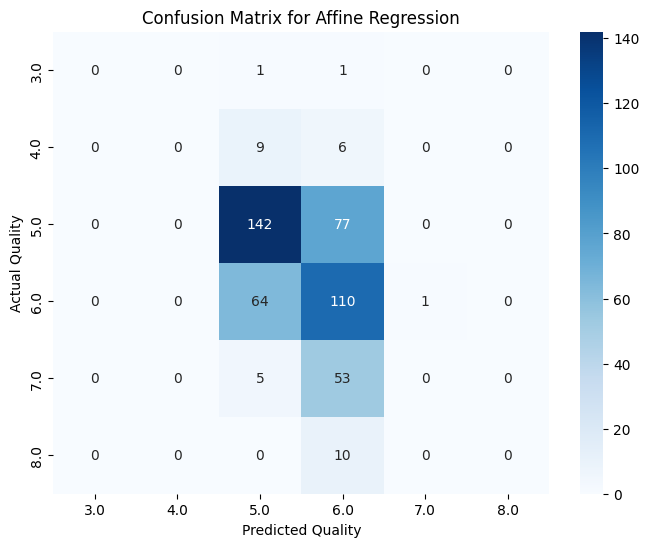

In [88]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=quality_labels, yticklabels=quality_labels)
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Confusion Matrix for Affine Regression')
plt.show()

In [134]:
from sklearn.metrics import make_scorer
def custom_scorer(y_true, y_pred):
    y_true_vals = np.argmax(y_true, axis=1) + 3
    predicted_quality_values = np.argmax(y_pred, axis=1) + 3
    return np.mean(y_true_vals == predicted_quality_values)

myScorer = make_scorer(custom_scorer, greater_is_better=True)

krr_rbf = KernelRidge(kernel='rbf')
krr_laplace = KernelRidge(kernel='laplacian')
krr_polynomial = KernelRidge(kernel='polynomial')

## Use custom scoring

In [169]:
param_grid_polynomial_c = {
    'alpha': [10**(-1), 1, 5],
    'degree': [2, 3],
    'coef0': [0.0, 1.0, 3.0]
}


grid_search_polynomial_c = GridSearchCV(
    krr_polynomial,
    param_grid=param_grid_polynomial_c,
    scoring=myScorer,
    cv=10,
    n_jobs=-1
)

grid_search_polynomial_c.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=KernelRidge(kernel='polynomial'), n_jobs=-1,
             param_grid={'alpha': [0.1, 1, 5], 'coef0': [0.0, 1.0, 3.0],
                         'degree': [2, 3]},
             scoring=make_scorer(custom_scorer, response_method='predict'))

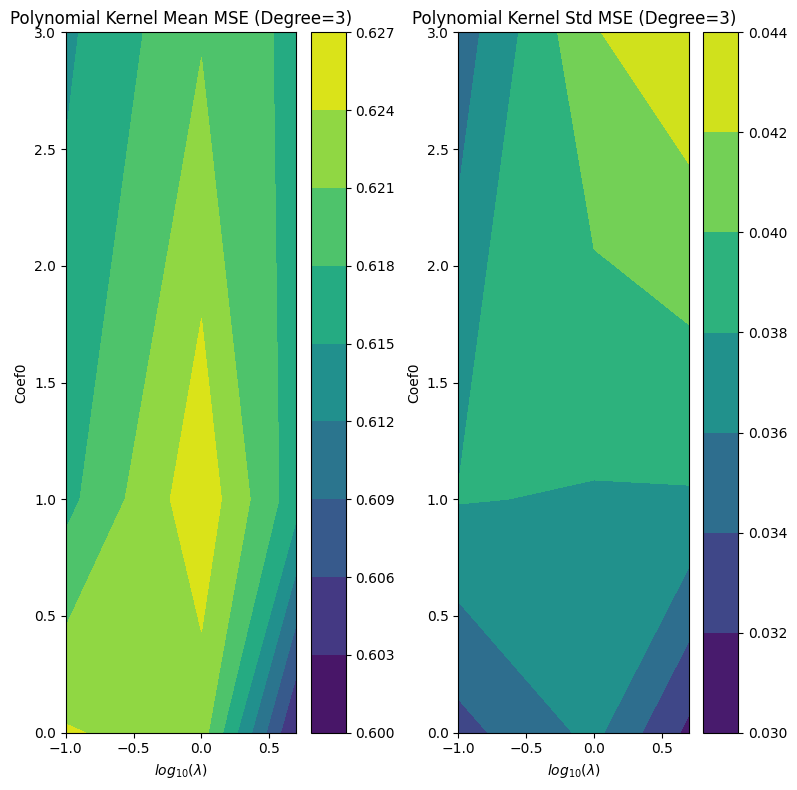

In [170]:
# Extract results for the best degree from GridSearchCV
best_degree_poly_c = grid_search_polynomial_c.best_params_['degree']
df_results_c = pd.DataFrame(grid_search_polynomial_c.cv_results_)

# Filter results for the best degree
poly_results_filtered_c = df_results_c[df_results_c['param_degree'] == 3]

alphas_polyc = sorted(poly_results_filtered_c['param_alpha'].unique())
coef0s_polyc = sorted(poly_results_filtered_c['param_coef0'].unique())

poly_lv_c, poly_sv_c = np.meshgrid(np.log10(alphas_polyc), coef0s_polyc)

mean_scores_poly_c = poly_results_filtered_c.pivot(index='param_coef0', columns='param_alpha', values='mean_test_score').values
std_scores_poly_c = poly_results_filtered_c.pivot(index='param_coef0', columns='param_alpha', values='std_test_score').values

fig, ax = plt.subplots(1,2, figsize=(8,8))

# Polynomial Mean Score
cm4c = ax[0].contourf(poly_lv_c, poly_sv_c, np.abs(mean_scores_poly_c), cmap='viridis')
ax[0].set_xlabel('$log_{10}(\\lambda)$')
ax[0].set_ylabel('Coef0')
ax[0].set_title(f'Polynomial Kernel Mean Custom Score (Degree={3})')
fig.colorbar(cm4c, ax=ax[0])

# Polynomial Std Score
cm5c = ax[1].contourf(poly_lv_c, poly_sv_c, np.abs(std_scores_poly_c), cmap='viridis')
ax[1].set_xlabel('$log_{10}(\\lambda)$')
ax[1].set_ylabel('Coef0')
ax[1].set_title(f'Polynomial Kernel Std Customer Score (Degree={3})')
fig.colorbar(cm5c, ax=ax[1])

fig.tight_layout()

## Regular Scoring

In [138]:
param_grid_polynomial = {
    'alpha': [10, 10**(2), 10**(5)],
    'degree': [1, 2, 3],
    'coef0': [0.0, 5.0, 10.0]
}


grid_search_polynomial = GridSearchCV(
    krr_polynomial,
    param_grid=param_grid_polynomial,
    scoring='neg_mean_squared_error',
    cv=10,
    n_jobs=-1
)

grid_search_polynomial.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=KernelRidge(kernel='polynomial'), n_jobs=-1,
             param_grid={'alpha': [10, 100, 100000], 'coef0': [0.0, 5.0, 10.0],
                         'degree': [1, 2, 3]},
             scoring='neg_mean_squared_error')

In [91]:
K_sgm = 10
K_lmbd = 10

sgm = np.linspace(1, 5, K_sgm)
lmbd = np.linspace(-2, 2, K_lmbd)

scores = np.zeros((K_sgm, K_lmbd, 2))
scores_std = np.zeros((K_sgm, K_lmbd, 2))

for i in range(K_sgm):

  krr_rbf.gamma = 1/(2*(sgm[i]**2))
  krr_laplace.gamma = 1/sgm[i]

  for j in range(K_lmbd):

    krr_rbf.alpha = (10**lmbd[j])
    krr_laplace.alpha = (10**lmbd[j])

    rbf_sc = sklearn.model_selection.cross_val_score(krr_rbf, X_train, y_train, scoring= 'neg_mean_squared_error', cv=10)
    laplace_sc = sklearn.model_selection.cross_val_score(krr_laplace, X_train, y_train, scoring= 'neg_mean_squared_error', cv=10)

    scores[i,j, 0] = (np.mean(rbf_sc))
    scores_std[i,j,0] = (np.std(rbf_sc))
    scores[i,j, 1] = (np.mean(laplace_sc))
    scores_std[i,j,1] = (np.std(laplace_sc))


In [140]:
rbf_sgm_idx, rbf_lmbd_idx = np.unravel_index(np.argmax(scores[:,:,0]), scores[:,:,0].shape)
lap_sgm_idx, lap_lmbd_idx = np.unravel_index(np.argmax(scores[:,:,1]), scores[:,:,1].shape)

print(f"Best RBF Lambda: {lmbd[rbf_lmbd_idx]}")
print(f"Best RBF Sigma: {sgm[rbf_sgm_idx]}")
print(f"Best Laplace Lambda: {lmbd[lap_lmbd_idx]}")
print(f"Best Laplace Sigma: {sgm[lap_sgm_idx]}")
print(f"Best Parameters for Polynomial KRR: {grid_search_polynomial.best_params_}")

Best RBF Lambda: -0.22222222222222232
Best RBF Sigma: 1.8888888888888888
Best Laplace Lambda: -0.6666666666666667
Best Laplace Sigma: 2.7777777777777777
Best Parameters for Polynomial KRR: {'alpha': 100, 'coef0': 5.0, 'degree': 3}


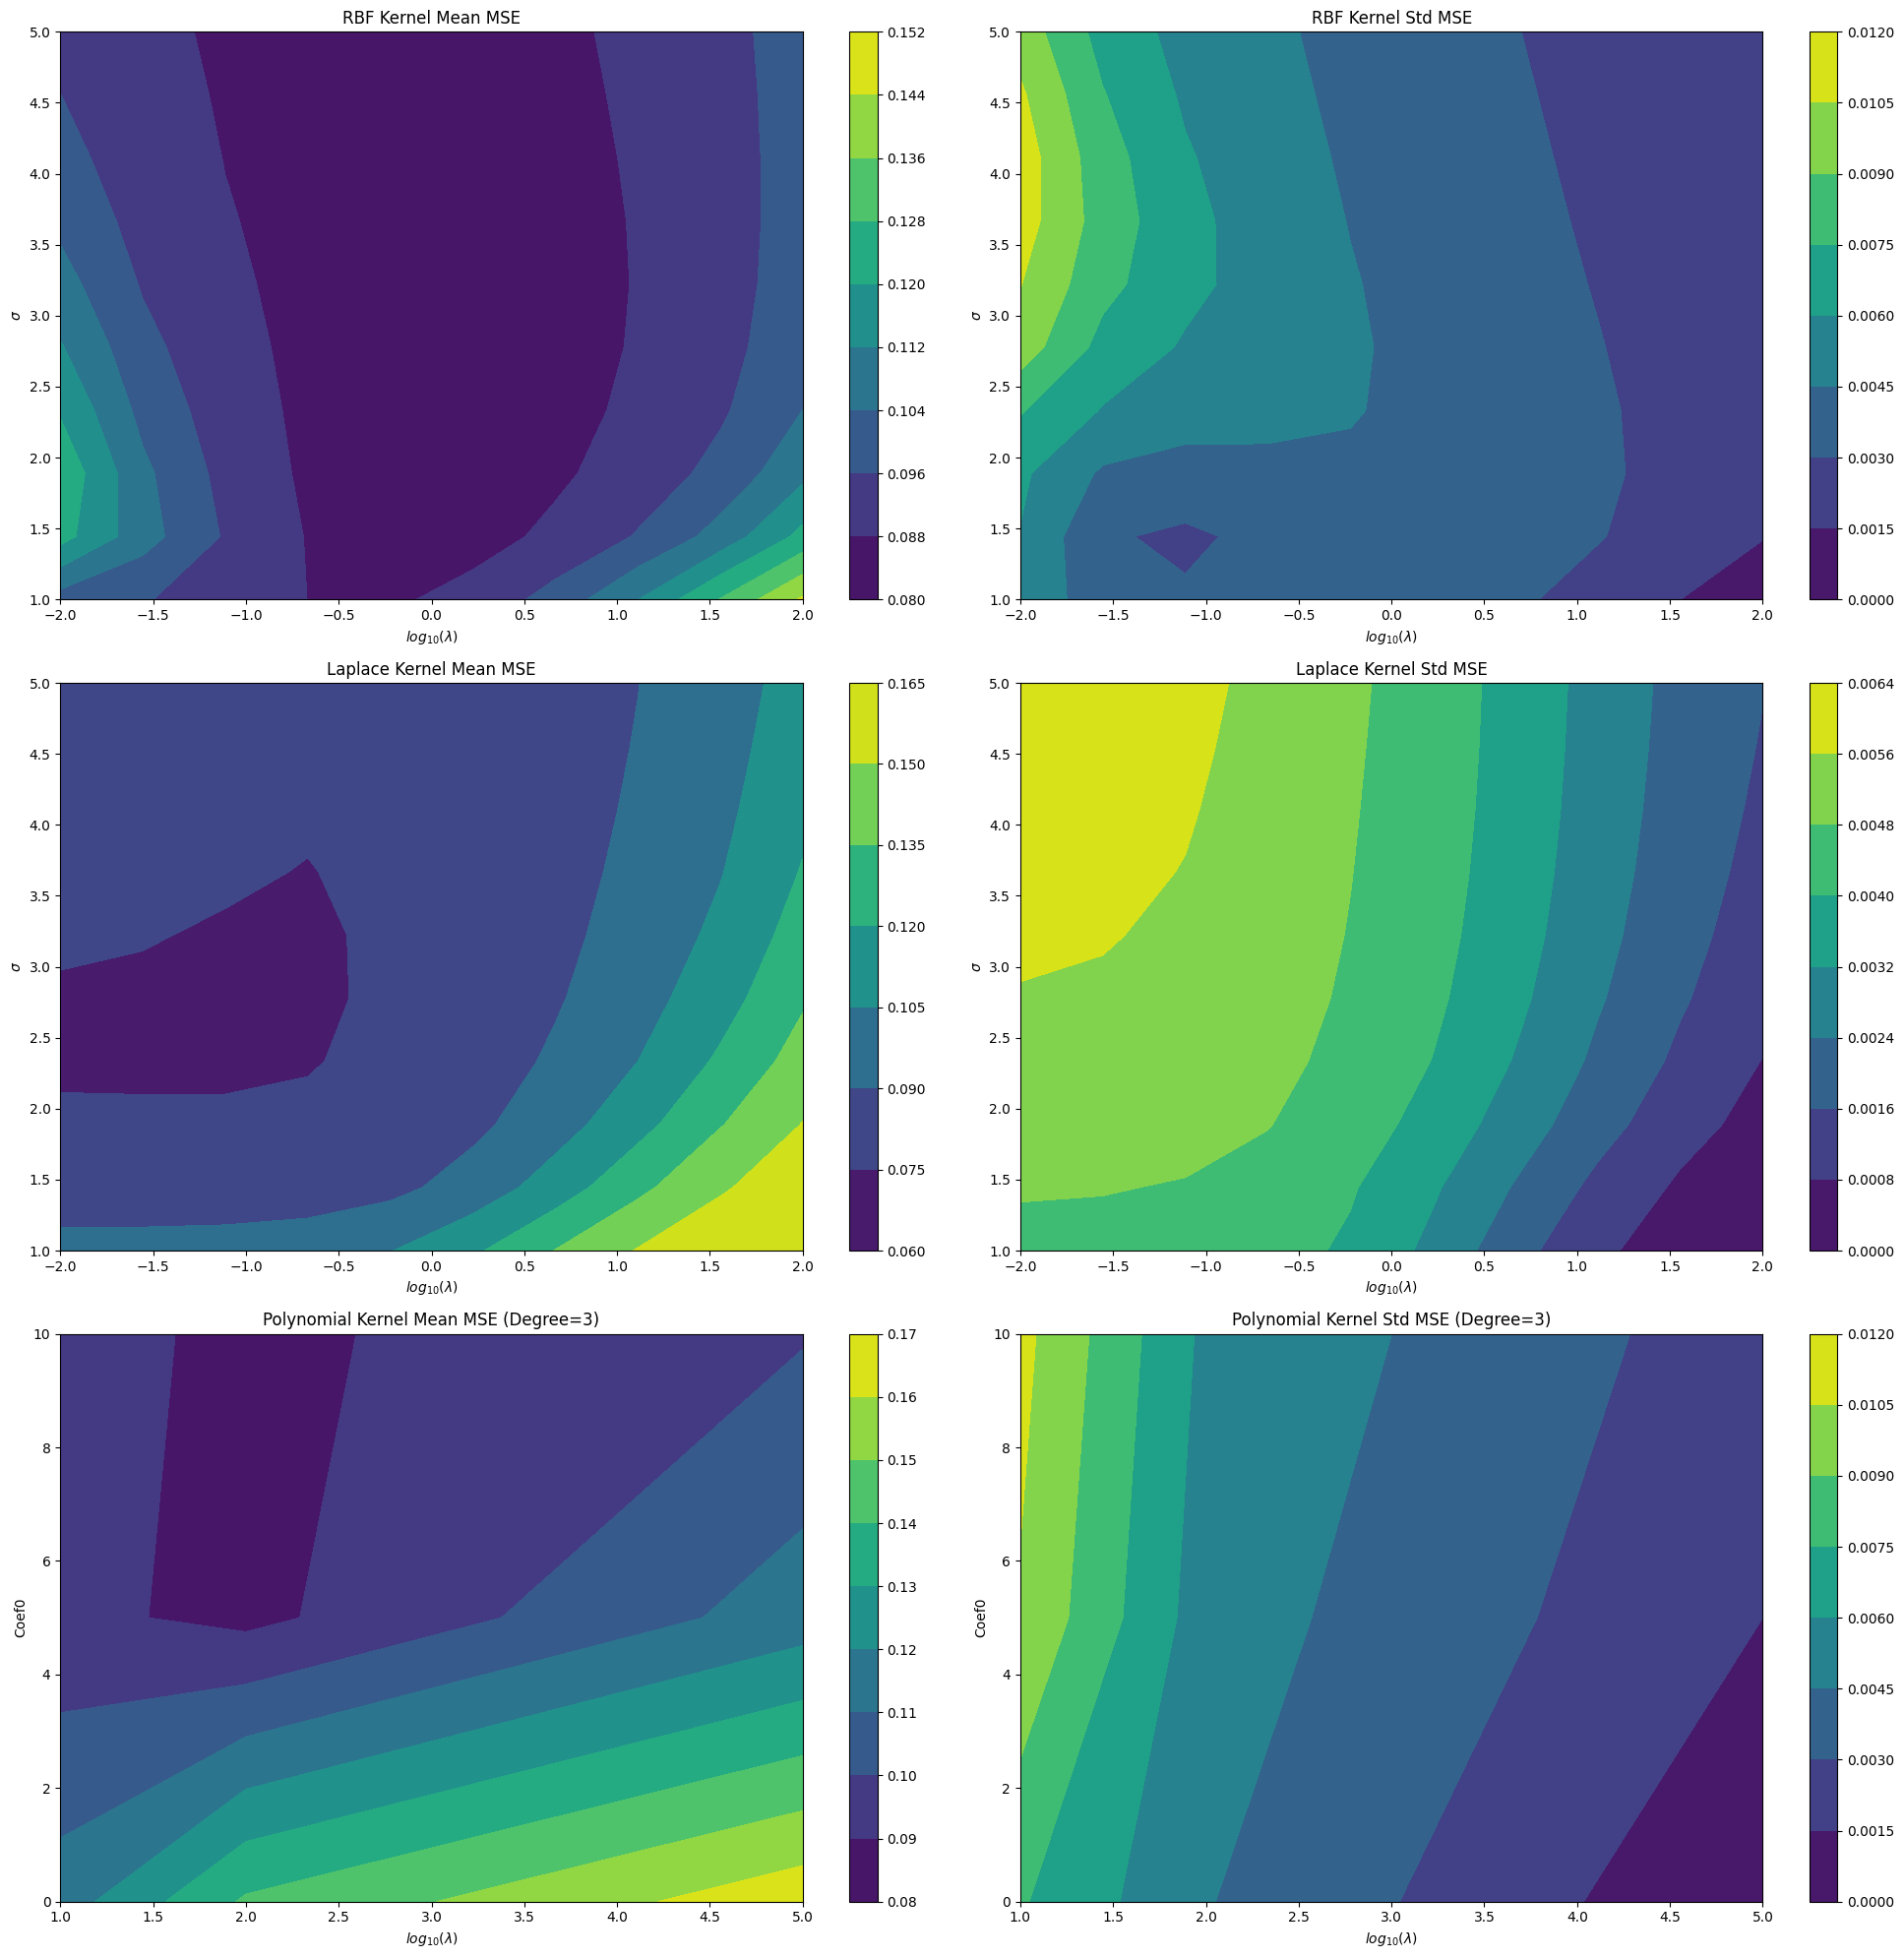

In [142]:
lv, sv = np.meshgrid(lmbd, sgm)

# Extract results for the best degree from GridSearchCV
best_degree_poly = grid_search_polynomial.best_params_['degree']
df_results = pd.DataFrame(grid_search_polynomial.cv_results_)

# Filter results for the best degree
poly_results_filtered = df_results[df_results['param_degree'] == 3]

alphas_poly = sorted(poly_results_filtered['param_alpha'].unique())
coef0s_poly = sorted(poly_results_filtered['param_coef0'].unique())

poly_lv, poly_sv = np.meshgrid(np.log10(alphas_poly), coef0s_poly)

mean_scores_poly = poly_results_filtered.pivot(index='param_coef0', columns='param_alpha', values='mean_test_score').values
std_scores_poly = poly_results_filtered.pivot(index='param_coef0', columns='param_alpha', values='std_test_score').values

fig, ax = plt.subplots(3,2, figsize=(20,20))
ax = ax.flatten()

# RBF Mean Score
cm0 = ax[0].contourf( lv, sv, np.abs(scores[:,:,0]))
ax[0].set_xlabel('$log_{10}(\\lambda)$')
ax[0].set_ylabel('$\\sigma$')
ax[0].set_title('RBF Kernel Mean MSE')
fig.colorbar(cm0, ax=ax[0])

# RBF Std Score
cm1 = ax[1].contourf(lv, sv, np.abs(scores_std[:,:,0]))
ax[1].set_xlabel('$log_{10}(\\lambda)$')
ax[1].set_ylabel('$\\sigma$')
ax[1].set_title('RBF Kernel Std MSE')
fig.colorbar(cm1, ax=ax[1])

# Laplace Mean Score
cm2 = ax[2].contourf( lv, sv, np.abs(scores[:,:,1]))
ax[2].set_xlabel('$log_{10}(\\lambda)$')
ax[2].set_ylabel('$\\sigma$')
ax[2].set_title('Laplace Kernel Mean MSE')
fig.colorbar(cm2, ax=ax[2])

# Laplace Std Score
cm3 = ax[3].contourf(lv, sv, np.abs(scores_std[:,:,1]))
ax[3].set_xlabel('$log_{10}(\\lambda)$')
ax[3].set_ylabel('$\\sigma$')
ax[3].set_title('Laplace Kernel Std MSE')
fig.colorbar(cm3, ax=ax[3])

# Polynomial Mean Score
cm4 = ax[4].contourf(poly_lv, poly_sv, np.abs(mean_scores_poly), cmap='viridis')
ax[4].set_xlabel('$log_{10}(\\lambda)$')
ax[4].set_ylabel('Coef0')
ax[4].set_title(f'Polynomial Kernel Mean MSE (Degree={3})')
fig.colorbar(cm4, ax=ax[4])

# Polynomial Std Score
cm5 = ax[5].contourf(poly_lv, poly_sv, np.abs(std_scores_poly), cmap='viridis')
ax[5].set_xlabel('$log_{10}(\\lambda)$')
ax[5].set_ylabel('Coef0')
ax[5].set_title(f'Polynomial Kernel Std MSE (Degree={3})')
fig.colorbar(cm5, ax=ax[5])

fig.tight_layout()

# Run Hypertuned Models

In [162]:
krr_rbf = KernelRidge(kernel='rbf', gamma=1/(2*(3.0)**2), alpha = 10**(0.75))
krr_laplace = KernelRidge(kernel='laplacian', gamma=1/3, alpha = 10**(-0.75))
best_krr_polynomial = KernelRidge(kernel='polynomial', degree=3, coef0=1, alpha=10**(0.05))


# Fit on training data using the one-hot encoded y_train
krr_rbf.fit(X_train, y_train)
krr_laplace.fit(X_train, y_train)
best_krr_polynomial.fit(X_train, y_train)

# Predict on test data
y_hat_rbf = krr_rbf.predict(X_test)
y_hat_laplace = krr_laplace.predict(X_test)
y_hat_polynomial_tuned = best_krr_polynomial.predict(X_test)

pred_rbf = np.argmax(y_hat_rbf, axis=1) + 3
pred_laplace = np.argmax(y_hat_laplace, axis=1) + 3
pred_polynomial_tuned = np.argmax(y_hat_polynomial_tuned, axis=1) + 3

acc_rbf = np.mean(pred_rbf == y_test)
acc_laplace = np.mean(pred_laplace == y_test)
acc_poly_tuned = np.mean(pred_polynomial_tuned == y_test)


print(f"Accuracy (RBF): {acc_rbf:.2%}")
print(f"Accuracy (Laplacian): {acc_laplace:.2%}")
print(f"Accuracy (Polynomial): {acc_poly_tuned:.2%}")

Accuracy (RBF): 58.66%
Accuracy (Laplacian): 64.72%
Accuracy (Polynomial): 58.66%


In [121]:
y_hat_temp = np.argmax(krr_laplace.predict(X_train), axis=1) + 3
acc_temp = np.mean(y_hat_temp == raw_train['quality'])
print(f"Acc Temp: {acc_temp:.2%}")

Acc Temp: 100.00%


In [122]:
cm_rbf = confusion_matrix(y_test, pred_rbf)
cm_lap = confusion_matrix(y_test, pred_laplace)
cm_poly = confusion_matrix(y_test, pred_polynomial_tuned)

quality_labels = np.unique(y_test)

print("Confusion Matrix (rbf):")
print(cm_rbf)

print("\nConfusion Matrix (lap):")
print(cm_lap)

print("\nConfusion Matrix (poly):")
print(cm_poly)
print("\nQuality Labels:")
print(quality_labels)

Confusion Matrix (rbf):
[[  0   0   2   0   0   0]
 [  0   0  11   4   0   0]
 [  0   0 143  76   0   0]
 [  0   0  49 119   7   0]
 [  0   0   5  34  19   0]
 [  0   0   0   5   5   0]]

Confusion Matrix (lap):
[[  0   0   2   0   0   0]
 [  0   0   8   7   0   0]
 [  0   2 162  53   2   0]
 [  0   1  45 115  14   0]
 [  0   0   5  20  33   0]
 [  0   0   0   5   5   0]]

Confusion Matrix (poly):
[[  0   0   2   0   0   0]
 [  0   0  11   4   0   0]
 [  0   0 139  79   1   0]
 [  0   1  51 117   6   0]
 [  0   0   6  35  17   0]
 [  0   0   0   6   4   0]]

Quality Labels:
[3. 4. 5. 6. 7. 8.]


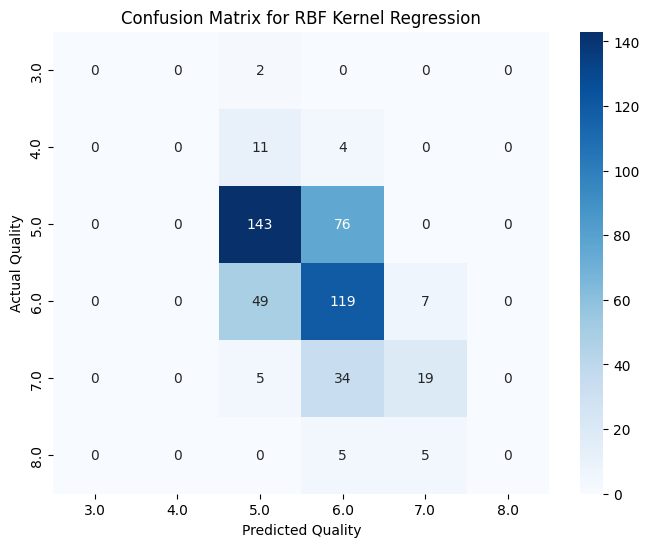

In [123]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Blues', xticklabels=quality_labels, yticklabels=quality_labels)
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Confusion Matrix for RBF Kernel Regression')
plt.show()

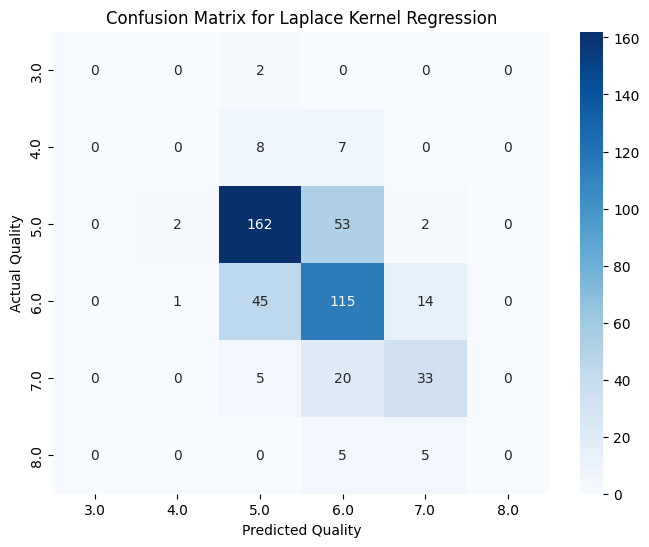

In [124]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lap, annot=True, fmt='d', cmap='Blues', xticklabels=quality_labels, yticklabels=quality_labels)
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Confusion Matrix for Laplace Kernel Regression')
plt.show()

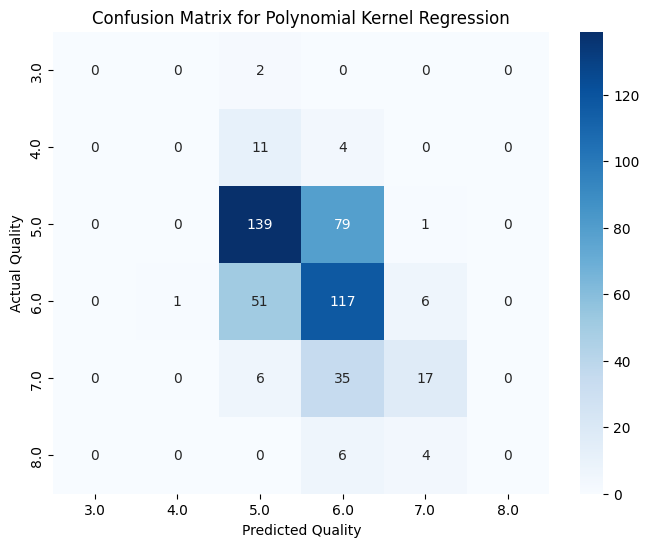

In [125]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_poly, annot=True, fmt='d', cmap='Blues', xticklabels=quality_labels, yticklabels=quality_labels)
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Confusion Matrix for Polynomial Kernel Regression')
plt.show()

# Predict New Wines

In [126]:
raw_newWines = pd.read_csv('wine_new_batch.csv', names= feature_columns)
new_data_t = scaler.transform(raw_newWines[feature_columns])
newX_test = np.hstack((np.ones((new_data_t.shape[0], 1)), new_data_t))

newy_hat_rbf = krr_rbf.predict(newX_test)
newy_hat_laplace = krr_laplace.predict(newX_test)
newy_hat_polynomial_tuned = best_krr_polynomial.predict(newX_test)

newPred_rbf = np.argmax(newy_hat_rbf, axis=1) + 3
newPred_laplace = np.argmax(newy_hat_laplace, axis=1) + 3
newPred_polynomial_tuned = np.argmax(newy_hat_polynomial_tuned, axis=1) + 3

print(f"Predicted Quality (RBF): {newPred_rbf}")
print(f"Predicted Quality (Laplacian): {newPred_laplace}")
print(f"Predicted Quality (Polynomial): {newPred_polynomial_tuned}")


Predicted Quality (RBF): [6 5 5 6 6]
Predicted Quality (Laplacian): [6 5 5 7 7]
Predicted Quality (Polynomial): [6 5 5 6 6]


In [127]:
predicted_rbf_series = pd.Series(newPred_rbf, name='Predicted Quality (RBF)')
predicted_laplace_series = pd.Series(newPred_laplace, name='Predicted Quality (Laplacian)')
predicted_polynomial_series = pd.Series(newPred_polynomial_tuned, name='Predicted Quality (Polynomial)')

newWines_df = pd.concat([
    raw_newWines,
    predicted_rbf_series,
    predicted_laplace_series,
    predicted_polynomial_series
], axis=1)

print(newWines_df)


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            6.2              0.21         0.29             1.6      0.039   
1            6.6              0.32         0.36             8.0      0.047   
2            6.5              0.24         0.19             1.2      0.041   
3            5.5              0.29         0.30             1.1      0.022   
4            6.0              0.21         0.38             0.8      0.020   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                   24                    92  0.99114  3.27       0.50   
1                   57                   168  0.99490  3.15       0.46   
2                   30                   111  0.99254  2.99       0.46   
3                   20                   110  0.98869  3.34       0.38   
4                   22                    98  0.98941  3.26       0.32   

   alcohol  Predicted Quality (RBF)  Predicted Quality (Laplacian)  \
0     11.2      